In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:22px;}
</style>
"""))

In [2]:
# GPU 활성화 끄기
import os
os.environ['CUDA_VISIBLE_DEVICES'] = "-1"
# GPU 사용 여부 확인
import tensorflow as tf
print(tf.__version__)
tf.config.list_physical_devices('GPU')

2.10.0


[]

# 1. 기존의 프로그램 방식

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# 섭씨온도(input data)를 받아 화씨 온도로 출력
def celsius_to_faherenheit(c):
    return 1.8*c + 32

In [ ]:
input_data = int(input('섭씨온도는?'))
print('화씨온도는 ', celsius_to_faherenheit(input_data))

# 2. 머신러닝/딥러닝 프로그램 방식
- 1. 데이터 확보 및 생성
- 2. 데이터 전처리 : scale조정, 라벨링처리, 훈련데이터셋(학습데이터셋), 검증데이터셋, 시험데이터셋으로 나누기
- 3. 모델구성
- 4. 모델 학습과정 설정
- 5. 모델 학습시키기(학습데이터셋과 검증데이터셋으로)
- 6. 모델 평가(시험데이터셋으로)
- 7. 모델 사용(입력값이 주어지면 예측값을 받기)

## 2.1 노이즈가 없는 데이터로 실습

In [5]:
# 1. 데이터 생성
data_C = np.arange(100)
data_C # 입력변수==독립변수

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [6]:
data_F = celsius_to_faherenheit(data_C)
data_F # 타겟변수==종속변수

array([ 32. ,  33.8,  35.6,  37.4,  39.2,  41. ,  42.8,  44.6,  46.4,
        48.2,  50. ,  51.8,  53.6,  55.4,  57.2,  59. ,  60.8,  62.6,
        64.4,  66.2,  68. ,  69.8,  71.6,  73.4,  75.2,  77. ,  78.8,
        80.6,  82.4,  84.2,  86. ,  87.8,  89.6,  91.4,  93.2,  95. ,
        96.8,  98.6, 100.4, 102.2, 104. , 105.8, 107.6, 109.4, 111.2,
       113. , 114.8, 116.6, 118.4, 120.2, 122. , 123.8, 125.6, 127.4,
       129.2, 131. , 132.8, 134.6, 136.4, 138.2, 140. , 141.8, 143.6,
       145.4, 147.2, 149. , 150.8, 152.6, 154.4, 156.2, 158. , 159.8,
       161.6, 163.4, 165.2, 167. , 168.8, 170.6, 172.4, 174.2, 176. ,
       177.8, 179.6, 181.4, 183.2, 185. , 186.8, 188.6, 190.4, 192.2,
       194. , 195.8, 197.6, 199.4, 201.2, 203. , 204.8, 206.6, 208.4,
       210.2])

In [7]:
# 2. 데이터 전처리 : 컴퓨터에게 학습시키기 위해, Normalize함(변수들의 편차를 비슷하게)
scaled_data_C = data_C/100.0
scaled_data_F = data_F/100.0
print('독립변수는 ', scaled_data_C)
print('종속변수는 ', scaled_data_F)

독립변수는  [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99]
종속변수는  [0.32  0.338 0.356 0.374 0.392 0.41  0.428 0.446 0.464 0.482 0.5   0.518
 0.536 0.554 0.572 0.59  0.608 0.626 0.644 0.662 0.68  0.698 0.716 0.734
 0.752 0.77  0.788 0.806 0.824 0.842 0.86  0.878 0.896 0.914 0.932 0.95
 0.968 0.986 1.004 1.022 1.04  1.058 1.076 1.094 1.112 1.13  1.148 1.166
 1.184 1.202 1.22  1.238 1.256 1.274 1.292 1.31  1.328 1.346 1.364 1.382
 1.4   1.418 1.436 1.454 1.472 1.49  1.508 1.526 1.544 1.562 1.58  1.598
 1.616 1.634 1.652 1.67  1.688 1.706 1.7

In [ ]:
# 3. 모델 구성(tensorflow)
from tensorflow.keras.models import Sequential # 모델 생성
from tensorflow.keras.layers import Dense # 입력값과 출력값으로 layer층 지정
model = Sequential()
model.add(Dense(1, # 출력(종속, 타겟)변수의 갯수
               input_shape=(1,) # 입력(독립)변수의 shape
               ))
print(model.summary())

-  회귀분석 오차함수 : 
    MSE(오차제곱평균), RMSE(루트를 취하기 때문에 MSE단점이 어느정도 해소. 덜 민감), MAE(절대값평균)

In [ ]:
# 4. 모델 학습 과정 설정
model.compile(loss='mse', optimizer='rmsprop', metrics=['mae'])
               # 손실함수          옵티마저이저      평가지표
# loss(오차, 손실함수)는 모델 학습 중 최적화할 대상
# metrics : 평가지표

In [ ]:
# 학습 전 예측
model.predict(np.array([[0],
                        [0.01]]))

In [ ]:
# 학습 전 모델 저장
model.save('model/before_learning.h5') # kernel에 w(기울기), bias에 b이 있음
# from tensorflow.keras.models import save_model
# save_model(model, 'model/before_learning.h5')

In [ ]:
# 모델 학습시키기 - 1번만 실행
hist = model.fit(scaled_data_C, scaled_data_F, epochs=1000, verbose=2)
                #  독립변수        타겟변수(종속)   학습횟수    학습시출력여부

In [ ]:
hist.history.keys()

In [ ]:
plt.plot(hist.history['loss'], 'r', label='loss')
plt.plot(hist.history['mae'], 'b', label='mae')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('error value')

In [22]:
# 모델 사용
model.predict(np.array([[0],
                        [0.01],
                        [0.02]]))

1/1 [==============================] - 0s 32ms/step


array([[0.32025048],
       [0.33825186],
       [0.35625327]], dtype=float32)

In [23]:
model.save('model/after_learning.h5')

In [24]:
# 모델 load
from tensorflow.keras.models import load_model
model = load_model('model/after_learning.h5')

In [25]:
y_hat = model.predict([scaled_data_C])
square_error = 0
for h, y in zip(y_hat, scaled_data_F):
    # print(h, y)
    square_error += (h[0]-y)**2
square_error/100 # mean square error(mse)

4/4 [==============================] - 0s 4ms/step


1.0354323956902936e-07

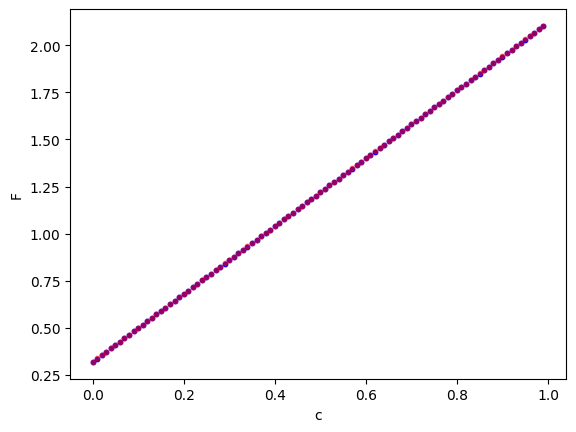

In [26]:
plt.scatter(x=scaled_data_C, y=scaled_data_F, c='b', s=10)
plt.scatter(x=scaled_data_C, y=y_hat, c='r', s=10, alpha=0.5)
plt.xlabel('c')
plt.ylabel('F')
plt.show()

## 2.2 노이즈가 있는 데이터로 실습

In [27]:
# 평균이 0이고 표준편차가 0.1인 넘파이 배열을 생성(size만큼)
np.random.seed(707)
noise = np.random.normal(0, scale=0.1, size=100)
noised_scaled_data_F = noise + scaled_data_F

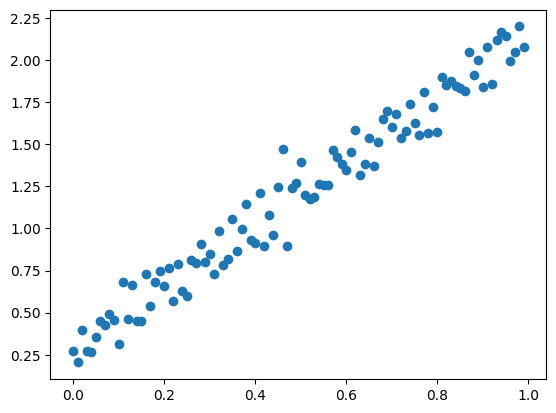

In [28]:
plt.scatter(x=scaled_data_C, y=noised_scaled_data_F)
plt.show()

In [29]:
# 3. 모델 구성(tensorflow)
from tensorflow.keras.models import Sequential # 모델 생성
from tensorflow.keras.layers import Dense # 입력값과 출력값으로 layer층 지정
model2 = Sequential()
model2.add(Dense(units=1, input_shape=(1, ))) # units출력갯수, input_shape입력shape
# 4. 학습과정 설정
model2.compile(loss='mse', optimizer='rmsprop', metrics=['mae'])
                # 손실함수          옵티마이저            평가지표
print(model2.summary())

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1 (Dense)             (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________
None


In [30]:
# 5. 학습시키기
hist2 = model2.fit(scaled_data_C, 
                   noised_scaled_data_F,
                   epochs=1000,
                   verbose=1)

Epoch 1/1000
4/4 [==============================] - 1s 3ms/step - loss: 2.7040 - mae: 1.4830
Epoch 2/1000
4/4 [==============================] - 0s 3ms/step - loss: 2.6663 - mae: 1.4711
Epoch 3/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.6411 - mae: 1.4632
Epoch 4/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.6199 - mae: 1.4566
Epoch 5/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.6004 - mae: 1.4505
Epoch 6/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.5815 - mae: 1.4445
Epoch 7/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.5619 - mae: 1.4383
Epoch 8/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.5423 - mae: 1.4319
Epoch 9/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.5218 - mae: 1.4254
Epoch 10/1000
4/4 [==============================] - 0s 2ms/step - loss: 2.5028 - mae: 1.4194
Epoch 11/1000
4/4 [==============================] - 0s 2ms/step - lo

4/4 [==============================] - 0s 2ms/step - loss: 0.4988 - mae: 0.5742
Epoch 175/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.4923 - mae: 0.5705
Epoch 176/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.4869 - mae: 0.5673
Epoch 177/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.4809 - mae: 0.5637
Epoch 178/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.4752 - mae: 0.5602
Epoch 179/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.4681 - mae: 0.5560
Epoch 180/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.4616 - mae: 0.5521
Epoch 181/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.4557 - mae: 0.5486
Epoch 182/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.4505 - mae: 0.5453
Epoch 183/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.4448 - mae: 0.5418
Epoch 184/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.1247 - mae: 0.3013
Epoch 347/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.1242 - mae: 0.3006
Epoch 348/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1237 - mae: 0.2998
Epoch 349/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1231 - mae: 0.2991
Epoch 350/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1225 - mae: 0.2982
Epoch 351/1000
4/4 [==============================] - 0s 1ms/step - loss: 0.1219 - mae: 0.2975
Epoch 352/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.1214 - mae: 0.2968
Epoch 353/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.1207 - mae: 0.2961
Epoch 354/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1201 - mae: 0.2954
Epoch 355/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.1192 - mae: 0.2944
Epoch 356/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.0417 - mae: 0.1720
Epoch 519/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0412 - mae: 0.1711
Epoch 520/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0409 - mae: 0.1703
Epoch 521/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0406 - mae: 0.1697
Epoch 522/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0402 - mae: 0.1690
Epoch 523/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0399 - mae: 0.1682
Epoch 524/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0396 - mae: 0.1675
Epoch 525/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0392 - mae: 0.1666
Epoch 526/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0389 - mae: 0.1661
Epoch 527/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0386 - mae: 0.1656
Epoch 528/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 2ms/step - loss: 0.0128 - mae: 0.0940
Epoch 691/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0128 - mae: 0.0941
Epoch 692/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0127 - mae: 0.0936
Epoch 693/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0127 - mae: 0.0936
Epoch 694/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0126 - mae: 0.0933
Epoch 695/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0126 - mae: 0.0931
Epoch 696/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0125 - mae: 0.0931
Epoch 697/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0125 - mae: 0.0930
Epoch 698/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0125 - mae: 0.0929
Epoch 699/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0124 - mae: 0.0927
Epoch 700/1000
4/4 [==============================] - 0s 2ms/step

4/4 [==============================] - 0s 1ms/step - loss: 0.0110 - mae: 0.0876
Epoch 863/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0876
Epoch 864/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0876
Epoch 865/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 866/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0876
Epoch 867/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0876
Epoch 868/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 869/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0877
Epoch 870/1000
4/4 [==============================] - 0s 2ms/step - loss: 0.0110 - mae: 0.0878
Epoch 871/1000
4/4 [==============================] - 0s 3ms/step - loss: 0.0110 - mae: 0.0879
Epoch 872/1000
4/4 [==============================] - 0s 2ms/step

In [31]:
hist2.history.keys()

dict_keys(['loss', 'mae'])

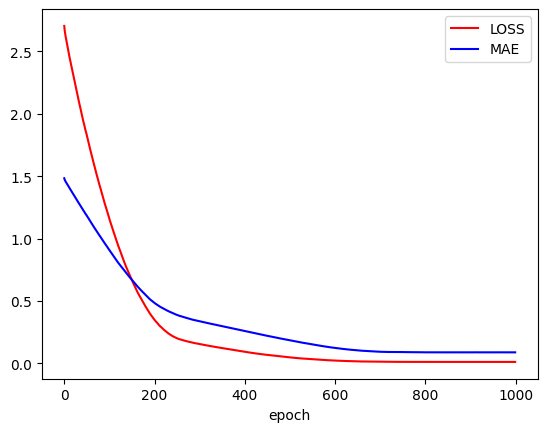

In [32]:
plt.plot(hist2.history['loss'], 'r', label='LOSS')
plt.plot(hist2.history['mae'], 'b', label='MAE')
plt.legend()
plt.xlabel('epoch')
plt.show()

In [34]:
y_hat = model2.predict([scaled_data_C])
square_error = 0
for h, y in zip(y_hat, noised_scaled_data_F):
    # print(h, y)
    square_error += (h[0]-y)**2
square_error/100 # mse

4/4 [==============================] - 0s 2ms/step


0.010944647218029038

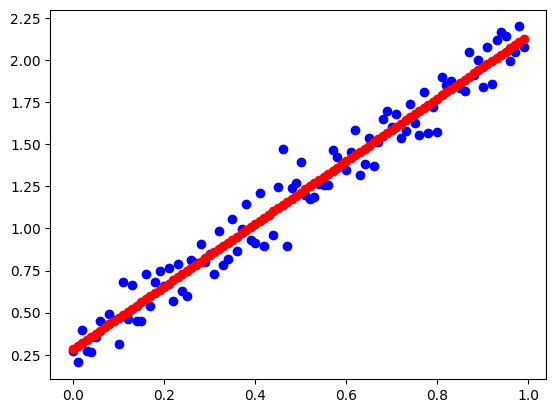

In [35]:
plt.scatter(x=scaled_data_C, y=noised_scaled_data_F, c='b')
plt.scatter(x=scaled_data_C, y=y_hat, c='r')